# 07. Large Dataset Handling

## 📚 Learning Objectives

By completing this notebook, you will:
- Load and process large datasets (chunking, etc.)
- Use distributed or out-of-core tools where relevant
- Summarize and visualize at scale

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lesson 01 (chunking) and Unit 5, lessons 02-03 — the practical decision procedure for data that will not fit in RAM.

**Used later in:** Course 12 (AIAT 126) — Unit 3, whose project data may well be this size.

---


## The Story

**BEFORE**: You can work with small datasets but don't know strategies for handling datasets that don't fit in memory.

**AFTER**: You'll learn strategies for large datasets: chunking, streaming, memory-efficient processing, and out-of-core computing!

**Why this matters**: Large Dataset Handling is essential for building complete, professional data science solutions!

---

# Unit 5 - Example 07: Large Dataset Handling

## 🔗 Solving the Problem from Example 06

**Remember the dead end from Example 06?**
- We learned performance optimization techniques
- But even optimized, very large datasets require special handling
- We needed strategies for handling massive datasets

**This notebook solves that problem!**
- We'll learn **large dataset handling strategies**
- We'll learn **chunking, streaming, and memory-efficient processing**
- We'll learn **techniques for datasets that don't fit in memory**

**This solves the large dataset problem from Example 06!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `cicids2017.csv` — a 708 MB packet-capture summary from the
  Canadian Institute for Cybersecurity: **2,300,825 real network flows** recorded
  over five days, each with 79 statistics and an attack label. No file is
  generated here; we stream a genuinely large one straight off disk.
- pandas (chunked reading), matplotlib

**Outputs:** What you'll see when you run the cells

- The whole 2.3-million-row file aggregated without ever holding it in memory
- Measured memory: whole-file DataFrame vs one chunk

---


In [1]:
# WHAT: Import the data stack and timing tools.
# WHY: This lesson is about processing data that would not fit comfortably in memory.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Print the banner.
# WHY: Goal framing: read, aggregate, and summarize a million-row file without loading it whole.

print("=" * 70)
print("=" * 70)
print("\n📚 Prerequisites: Examples 02-06 completed, memory management knowledge")
print("🔗 This is Example 07 in Unit 5 - large dataset handling")
print("🎯 Goal: Master processing large datasets efficiently")
print("Reference: Study 18.pdf before running this code example.\n")


📚 Prerequisites: Examples 02-06 completed, memory management knowledge
🔗 This is Example 07 in Unit 5 - large dataset handling
🎯 Goal: Master processing large datasets efficiently
Reference: Study 18.pdf before running this code example.



## 1. A Genuinely Large File

In [3]:
# WHAT: Point at a real 708 MB capture file and measure how many rows it holds by streaming it.
# WHY: You cannot chunk-process a file you have not sized up. Counting rows without
#      loading the file is itself the first chunking exercise.

print("\n1. A Genuinely Large Real File")
print("-" * 70)

import os

DATA_DIR = '../../../Course 04/datasets/raw/'
large_file = DATA_DIR + 'cicids2017.csv'

file_mb = os.path.getsize(large_file) / 1e6
print(f"File: cicids2017.csv")
print(f"Size on disk: {file_mb:,.0f} MB")

# The columns we care about. usecols is the cheapest optimisation there is:
# the parser skips the other 73 columns entirely.
USECOLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
           ' Total Backward Packets', ' Fwd Packet Length Mean', ' Label']
chunk_size = 200_000

# Count the rows by streaming - at no point is the whole file in memory.
start = time.time()
total_rows = 0
for chunk_df in pd.read_csv(large_file, usecols=USECOLS, chunksize=chunk_size):
    total_rows += len(chunk_df)
count_time = time.time() - start
n_chunks = -(-total_rows // chunk_size)   # ceiling division

print(f"\n✓ Streamed the whole file in {count_time:.2f}s without loading it")
print(f"✓ Rows: {total_rows:,} network flows, read in {n_chunks} chunks of {chunk_size:,}")

# Peek at the first rows so we know what we are aggregating.
verify_df = pd.read_csv(large_file, usecols=USECOLS, nrows=5)
verify_df.columns = [c.strip() for c in verify_df.columns]
print(f"✓ Columns kept: {list(verify_df.columns)}")
print(f"✓ Sample data:\n{verify_df.head().to_string()}")
print("\n💡 This file is real network telemetry, not something we generated. A")
print("   production sensor writes one of these every day - which is exactly why")
print("   'just load it into pandas' stops being an option.")


1. A Genuinely Large Real File
----------------------------------------------------------------------
File: cicids2017.csv
Size on disk: 708 MB



✓ Streamed the whole file in 2.13s without loading it
✓ Rows: 2,300,825 network flows, read in 12 chunks of 200,000
✓ Columns kept: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packet Length Mean', 'Label']
✓ Sample data:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Fwd Packet Length Mean   Label
0                88            640                  7                       4               62.857143  BENIGN
1                88            900                  9                       4               66.666667  BENIGN
2                88           1205                  7                       4              396.571429  BENIGN
3                88            511                  7                       4               64.571429  BENIGN
4                88            773                  9                       4               68.000000  BENIGN

💡 This file is real network telemetry, not something we generated. A
  

2. PROCESSING IN CHUNKS


In [4]:
# WHAT: Read the real capture in 200k-row chunks, aggregating each as it streams past.
# WHY: Chunked reading bounds memory: at any moment only one chunk lives in RAM.

print("\n\n2. Processing in Chunks")
print("-" * 70)

results = []
chunk_processing_times = []

start_total = time.time()
chunk_reader = pd.read_csv(large_file, usecols=USECOLS, chunksize=chunk_size)
for i, chunk_df in enumerate(chunk_reader, 1):
    chunk_start = time.time()

    # The CICIDS header has leading spaces in most column names - a real quirk
    # of this file. Strip them once per chunk rather than trusting the header.
    chunk_df.columns = chunk_df.columns.str.strip()

    # Per-chunk aggregation: mean flow duration per traffic label
    chunk_result = chunk_df.groupby('Label')['Flow Duration'].agg(['sum', 'count'])
    results.append(chunk_result)
    chunk_processing_times.append(time.time() - chunk_start)

    if i % 4 == 0:
        print(f"Processed chunk {i}/{n_chunks}, time: {chunk_processing_times[-1]:.4f}s")

total_time = time.time() - start_total

# Combine: sum the per-chunk sums and counts, THEN divide. Averaging the
# per-chunk means would be wrong whenever the chunks hold different row counts.
combined = pd.concat(results).groupby(level=0).sum()
final_result = (combined['sum'] / combined['count']).sort_values(ascending=False)

print(f"\n✓ Processed {len(results)} chunks in {total_time:.2f} seconds")
print(f"✓ Average chunk processing time: {np.mean(chunk_processing_times):.4f} seconds")
print(f"\nMean flow duration (microseconds) per traffic type, "
      f"across all {int(combined['count'].sum()):,} flows:")
print(final_result.round(0).to_string())
print("\n⚠️  Note the aggregation trick: we carried SUM and COUNT per chunk, not the")
print("   mean. Averaging chunk means only works when every chunk is the same size -")
print("   the last chunk here holds "
      f"{int(total_rows - (n_chunks - 1) * chunk_size):,} rows, not {chunk_size:,}.")



2. Processing in Chunks
----------------------------------------------------------------------


Processed chunk 4/12, time: 0.0055s


Processed chunk 8/12, time: 0.0048s


Processed chunk 12/12, time: 0.0032s

✓ Processed 12 chunks in 1.91 seconds
✓ Average chunk processing time: 0.0050 seconds

Mean flow duration (microseconds) per traffic type, across all 2,300,825 flows:
Label
Heartbleed                    110679708.0
Infiltration                   78407720.0
DoS Slowhttptest               57719892.0
DoS Hulk                       57081732.0
DoS slowloris                  56554365.0
DoS GoldenEye                  23127222.0
DDoS                           16955592.0
BENIGN                         11473608.0
Web Attack � XSS                6715357.0
Web Attack � Brute Force        6506182.0
SSH-Patator                     6168967.0
FTP-Patator                     4513245.0
Web Attack � Sql Injection      2870398.0
Bot                              350943.0
PortScan                          82820.0

⚠️  Note the aggregation trick: we carried SUM and COUNT per chunk, not the
   mean. Averaging chunk means only works when every chunk is the same size -
   t

3. MEMORY-EFFICIENT PROCESSING


In [5]:
# WHAT: Compute a global mean with a running sum and count over chunks.
# WHY: Many statistics decompose into per-chunk pieces - the essence of out-of-core and distributed computing.

print("\n\n3. Memory Efficient Processing")
print("-" * 70)
# Use iterator to process without loading all into memory
total_sum = 0
total_count = 0
print("Processing with iterator (memory-efficient)...")
start_time = time.time()

chunk_reader = pd.read_csv(large_file, usecols=[' Total Fwd Packets'], chunksize=chunk_size)
chunk_num = 0
for chunk_df in chunk_reader:
    chunk_num += 1
    chunk_df.columns = chunk_df.columns.str.strip()
    total_sum += chunk_df['Total Fwd Packets'].sum()
    total_count += len(chunk_df)

avg_packets = total_sum / total_count
iterator_time = time.time() - start_time
print(f"Average forward packets per flow (computed incrementally): {avg_packets:.2f}")
print(f"Total forward packets across the whole capture: {total_sum:,}")
print(f"Processing time: {iterator_time:.2f} seconds")
print(f"Memory used: minimal - one {chunk_size:,}-row chunk at a time")
print(f"Processed {chunk_num} chunks covering {total_count:,} flows")



3. Memory Efficient Processing
----------------------------------------------------------------------
Processing with iterator (memory-efficient)...


Average forward packets per flow (computed incrementally): 9.12
Total forward packets across the whole capture: 20,993,023
Processing time: 1.71 seconds
Memory used: minimal - one 200,000-row chunk at a time
Processed 12 chunks covering 2,300,825 flows


4. VISUALIZATION




4. Creating Visualization
----------------------------------------------------------------------


Measured DataFrame memory - load all 2,300,825 rows at once: 219.5 MB
Measured DataFrame memory - one 200,000-row chunk in RAM: 19.1 MB
→ Chunking keeps ~12x less data in memory at any moment
   (and that is with only 6 of the file's 79 columns selected)


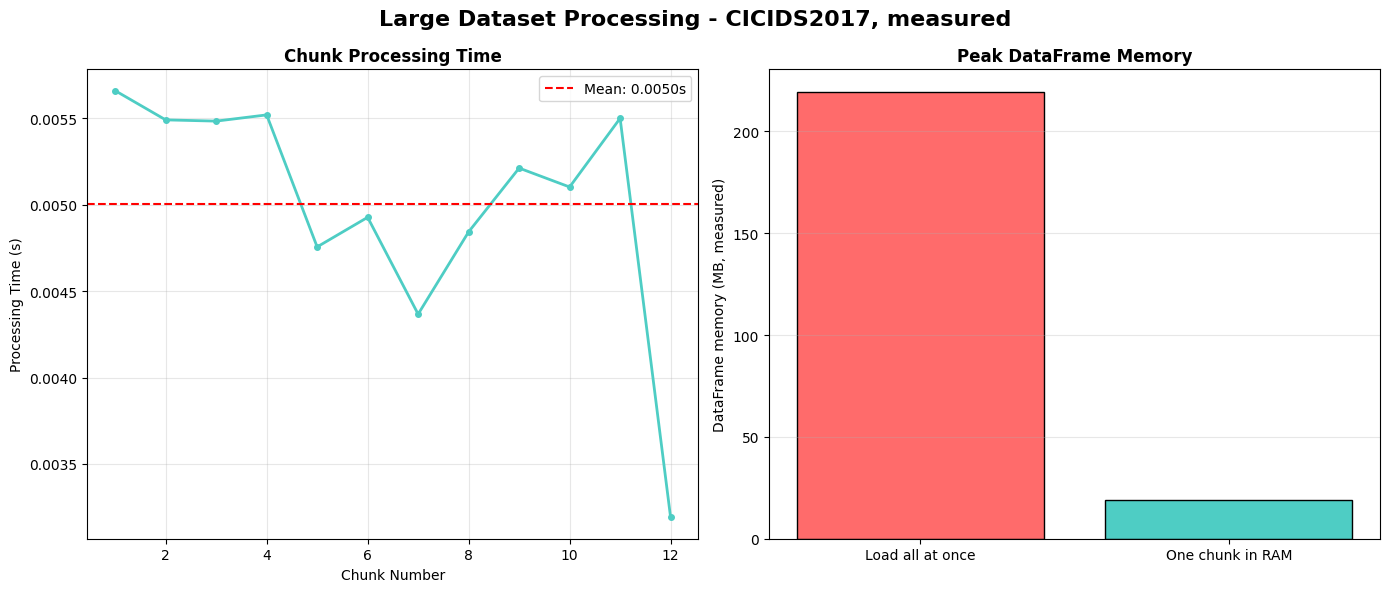

✓ Visualization created from measured values


In [6]:
# WHAT: Measure whole-file vs one-chunk memory and chart the per-chunk processing times.
# WHY: The measured ratio shows exactly how much RAM chunking saves - no invented numbers.

print("\n\n4. Creating Visualization")
print("-" * 70)

# MEASURE the memory difference instead of inventing numbers:
# full-file DataFrame vs a single chunk (what chunking keeps in RAM at once).
# NOTE: this is only for the six columns we selected. Loading all 79 columns of
# this file would need several gigabytes - which is the whole point.
df_full = pd.read_csv(large_file, usecols=USECOLS)
full_mem_mb = df_full.memory_usage(deep=True).sum() / 1e6
del df_full
one_chunk = next(pd.read_csv(large_file, usecols=USECOLS, chunksize=chunk_size))
chunk_mem_mb = one_chunk.memory_usage(deep=True).sum() / 1e6
del one_chunk
print(f"Measured DataFrame memory - load all {total_rows:,} rows at once: {full_mem_mb:.1f} MB")
print(f"Measured DataFrame memory - one {chunk_size:,}-row chunk in RAM: {chunk_mem_mb:.1f} MB")
print(f"→ Chunking keeps ~{full_mem_mb / chunk_mem_mb:.0f}x less data in memory at any moment")
print(f"   (and that is with only {len(USECOLS)} of the file's 79 columns selected)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Large Dataset Processing - CICIDS2017, measured', fontsize=16, weight='bold')
# Chunk processing times
axes[0].plot(range(1, len(chunk_processing_times) + 1), chunk_processing_times,
             marker='o', color='#4ECDC4', linewidth=2, markersize=4)
axes[0].axhline(y=np.mean(chunk_processing_times), color='r', linestyle='--',
                label=f'Mean: {np.mean(chunk_processing_times):.4f}s')
axes[0].set_xlabel('Chunk Number')
axes[0].set_ylabel('Processing Time (s)')
axes[0].set_title('Chunk Processing Time', fontsize=12, weight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Memory comparison - measured above
methods = ['Load all at once', 'One chunk in RAM']
memory_usage = [full_mem_mb, chunk_mem_mb]
axes[1].bar(methods, memory_usage, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1].set_ylabel('DataFrame memory (MB, measured)')
axes[1].set_title('Peak DataFrame Memory', fontsize=12, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('18_large_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualization created from measured values")

# 5. SUMMARY


In [7]:
# WHAT: Print the summary with the numbers this run measured.
# WHY: Chunking, streaming, and incremental aggregation scale the same pandas skills to bigger-than-RAM data.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
Measured on a real {file_mb:,.0f} MB capture file ({total_rows:,} network flows):

  Streamed row count      {count_time:.2f}s, file never fully in memory
  Chunked aggregation     {total_time:.2f}s over {len(results)} chunks
  Incremental global mean {iterator_time:.2f}s, {total_count:,} flows
  Peak DataFrame memory   {full_mem_mb:.0f} MB all at once vs {chunk_mem_mb:.0f} MB per chunk

Key Concepts Covered:
1. Chunking strategies (chunksize + usecols)
2. Streaming processing - the file stays on disk
3. Memory-efficient operations
4. Incremental aggregation - carry SUM and COUNT, divide at the end

Next Steps: Continue to Example 08 for Deployment
""")


Summary

Measured on a real 708 MB capture file (2,300,825 network flows):

  Streamed row count      2.13s, file never fully in memory
  Chunked aggregation     1.91s over 12 chunks
  Incremental global mean 1.71s, 2,300,825 flows
  Peak DataFrame memory   219 MB all at once vs 19 MB per chunk

Key Concepts Covered:
1. Chunking strategies (chunksize + usecols)
2. Streaming processing - the file stays on disk
3. Memory-efficient operations
4. Incremental aggregation - carry SUM and COUNT, divide at the end

Next Steps: Continue to Example 08 for Deployment



## 📚 References

1. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>
2. Rocklin, M. (2015). *Dask: Parallel Computation with Blocked Algorithms and Task Scheduling*. Proceedings of the 14th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-7b98e3ed-013>
3. Dean, J., & Ghemawat, S. (2004). *MapReduce: Simplified Data Processing on Large Clusters*. OSDI 2004. <https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/>